# Python Lesson 10: Determinant

**Concept page:** `wiki/concepts/determinant.md` · **Area:** linear-algebra

**You will be able to:**
- compute 2x2 and 3x3 determinants by formula, Sarrus and cofactors
- interpret |det| as area/volume scale
- verify det(AB)=det(A)det(B)

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. 2×2: ad − bc

In [2]:
def det2(M): return M[0][0]*M[1][1]-M[0][1]*M[1][0]
print(det2([[5,1],[-1,3]]), det2([[2,-1],[-6,3]]))   # 16 and 0 (Coursera quiz)

16 0


## 2. 3×3: Sarrus' rule and cofactor expansion

In [3]:
def sarrus(M):
    a=np.array(M,float)
    return (a[0,0]*a[1,1]*a[2,2]+a[0,1]*a[1,2]*a[2,0]+a[0,2]*a[1,0]*a[2,1]
           -a[0,2]*a[1,1]*a[2,0]-a[0,0]*a[1,2]*a[2,1]-a[0,1]*a[1,0]*a[2,2])
def cofactor_row1(M):
    a=np.array(M,float)
    return sum((-1)**j*a[0,j]*det2(np.delete(np.delete(a,0,0),j,1)) for j in range(3))
M3=[[1,2,3],[6,-3,5],[-4,0,-1]]
print(sarrus(M3), cofactor_row1(M3), np.linalg.det(M3))   # -61

-61.0 -61.0 -61.00000000000001


## 3. Area scale factor and product rule

In [4]:
A=np.array([[3,1],[1,2]]); B=np.array([[5,2],[1,2]])
print(np.linalg.det(A), np.linalg.det(B), np.linalg.det(A@B), np.linalg.det(A)*np.linalg.det(B))
print("orientation flip:", np.linalg.det(np.array([[1,3],[2,1]])))   # -5

5.000000000000001 7.999999999999998 40.0 40.0
orientation flip: -5.000000000000001


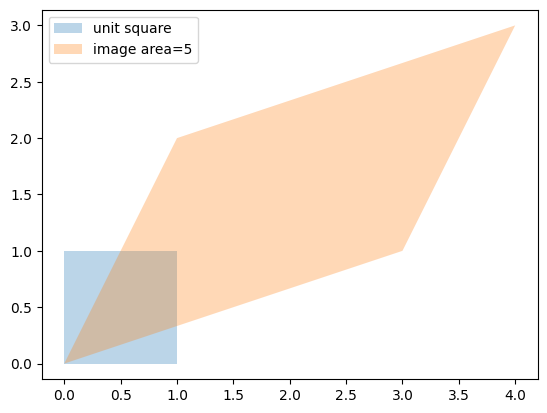

In [5]:
sq=np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
img=A@sq
plt.fill(sq[0],sq[1],alpha=.3,label="unit square"); plt.fill(img[0],img[1],alpha=.3,label=f"image area={abs(np.linalg.det(A)):.0f}")
plt.legend(); plt.axis('equal'); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 11 basic p. 131–132: Sarrus' rule gives |1 2 3; 6 −3 5; −4 0 −1| = −61.

In [6]:
print(sarrus(M3))

-61.0


## Exercises

**Exercise 1.** Compute the determinant of [[1,2],[2,4]] and say whether it is singular.

In [7]:
# your code here

**Exercise 2.** Verify numerically that scaling a row of a 3x3 matrix by k scales the determinant by k.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
d=det2([[1,2],[2,4]]); print(d); assert d==0

0


In [10]:
# Solution 2
M=np.array(M3,float); N=M.copy(); N[1]*=5; assert np.isclose(np.linalg.det(N),5*np.linalg.det(M))